<a href="https://colab.research.google.com/github/Salimam00/pinn-thermoelasticity-rods/blob/main/pinn_validation_and_convergence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Completed Successfully.


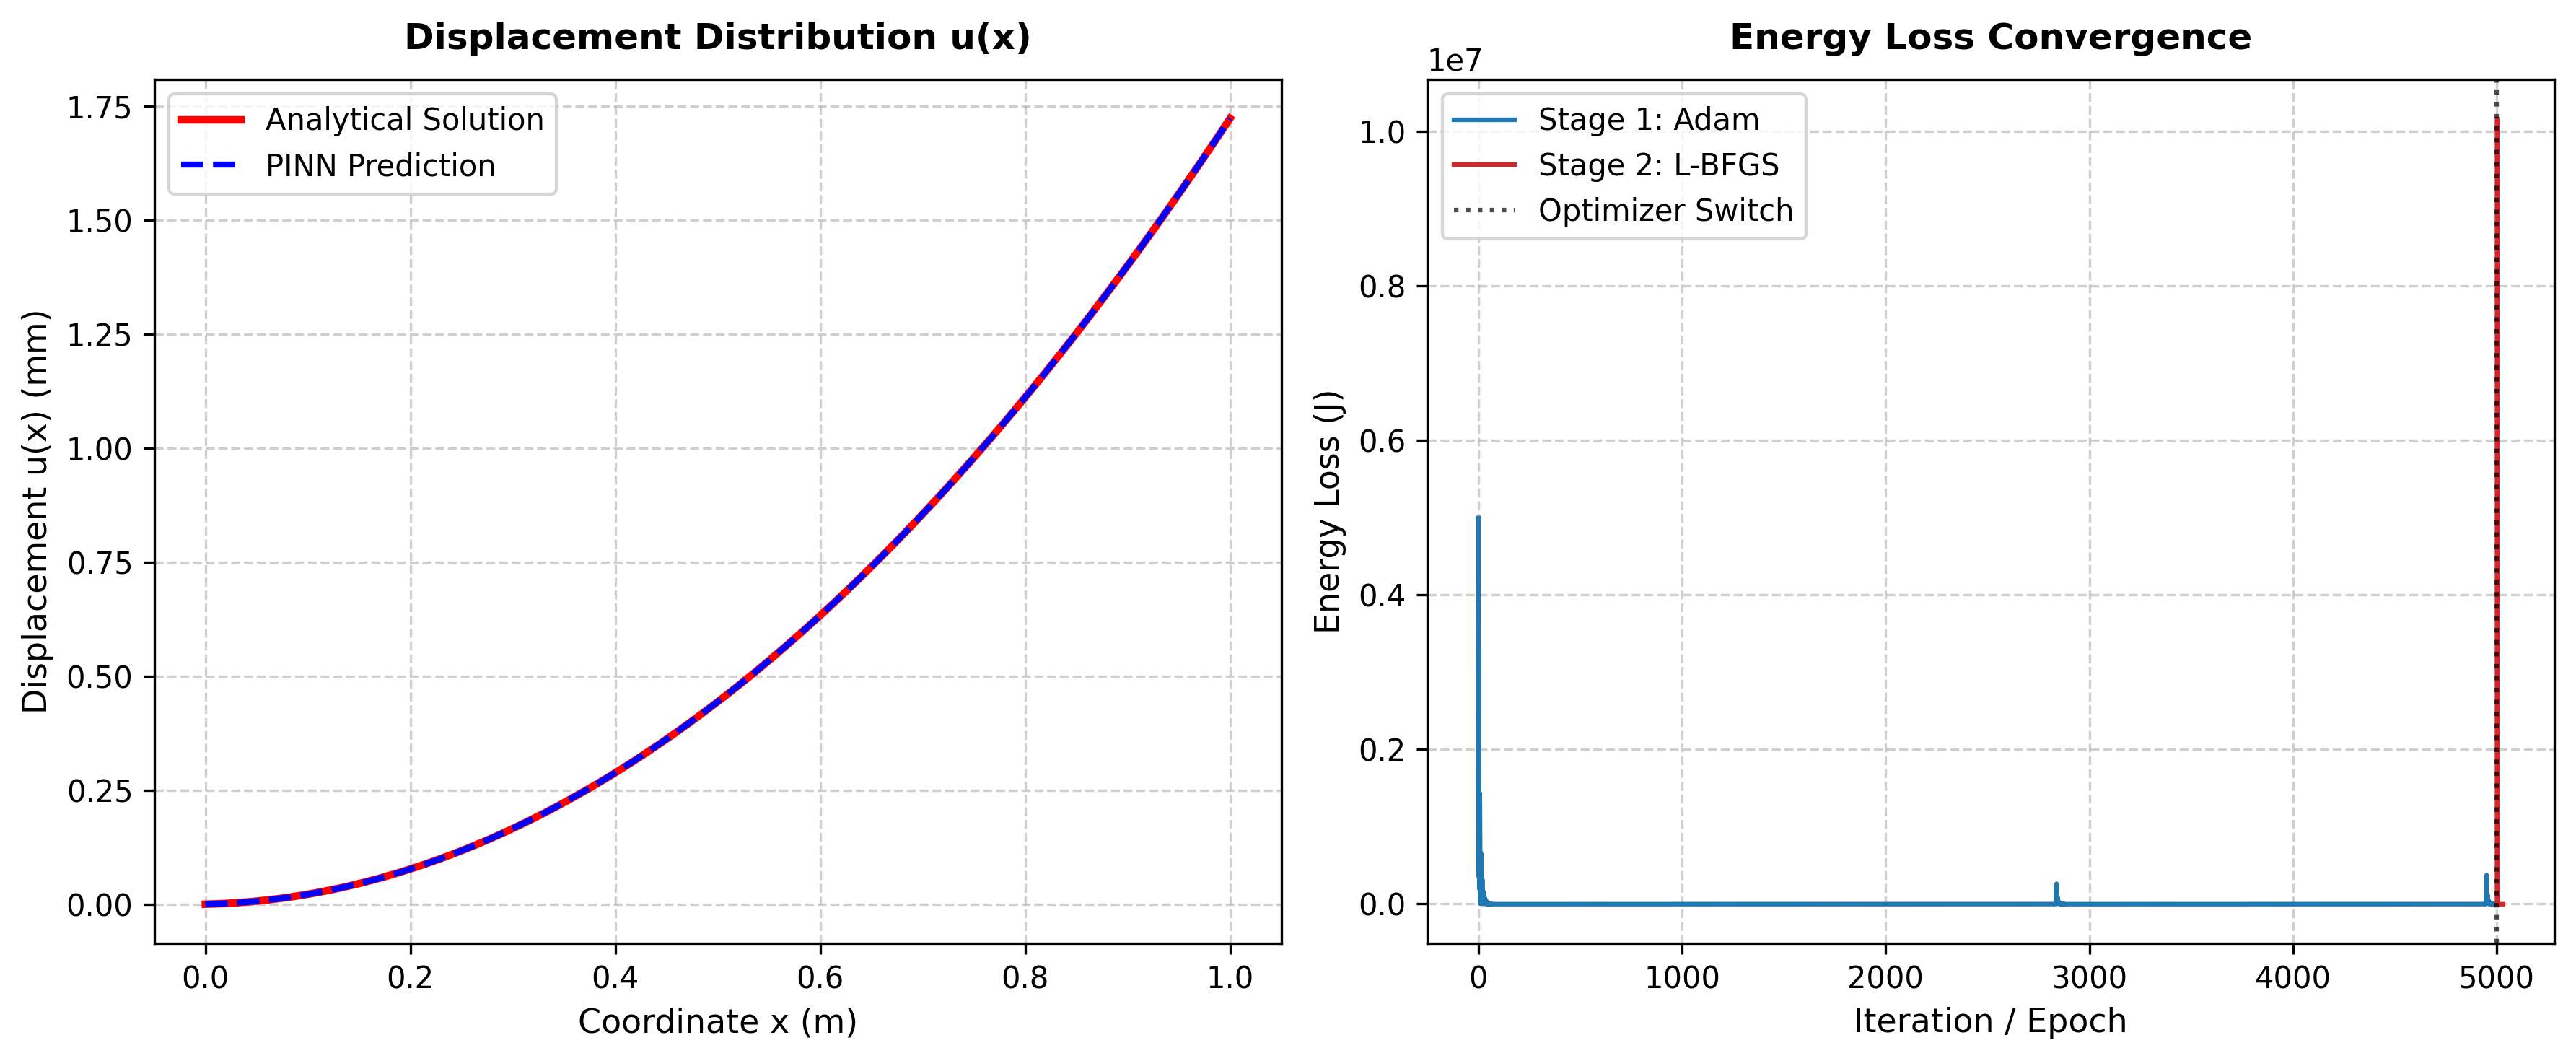

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

# Set random seed for reproducibility
torch.manual_seed(42)

# Physical and Geometrical Parameters
L = 1.0  # Rod length (m)
E = 2.0e11  # Young's Modulus (Pa) - Steel
alpha = 1.2e-5  # Thermal expansion coefficient (1/K)
T_0 = 20.0  # Initial temperature (deg C)
P_L = 1.0e5  # Tensile load at x=L (N)

A_0 = 0.01  # Initial Area (m^2)
beta = 0.5  # Taper parameter


def Area(x):
  return A_0 * (1.0 + beta * (x / L) ** 2)


Delta_T_max = 280.0  # Delta T at x=L (deg C)


def Temperature_Change(x):
  return Delta_T_max * (x / L)


# PINN Architecture
class PINN_Thermoelasticity(nn.Module):

  def __init__(self, hidden_layers=4, neurons_per_layer=50):
    super().__init__()
    layers = [nn.Linear(1, neurons_per_layer), nn.Tanh()]
    for _ in range(hidden_layers - 1):
      layers += [nn.Linear(neurons_per_layer, neurons_per_layer), nn.Tanh()]
    layers.append(nn.Linear(neurons_per_layer, 1))
    self.net = nn.Sequential(*layers)

  def forward(self, x):
    # Hard constraint: u(0) = 0 via u_hat = x * N(x)
    return x * self.net(x)


# Energy Loss Function (Variational Principle)
def compute_energy_loss(model, x_collocation):
  x_collocation.requires_grad_(True)
  u_pred = model(x_collocation)

  du_dx = torch.autograd.grad(
      outputs=u_pred,
      inputs=x_collocation,
      grad_outputs=torch.ones_like(u_pred),
      create_graph=True,
  )[0]

  A_x = Area(x_collocation)
  dT_x = Temperature_Change(x_collocation)

  elastic_density = 0.5 * E * A_x * (du_dx**2)
  thermal_density = E * A_x * alpha * dT_x * du_dx
  internal_energy = torch.mean(elastic_density - thermal_density) * L

  x_L = torch.tensor([[L]], dtype=torch.float32)
  u_L = model(x_L)
  external_work = P_L * u_L

  return internal_energy - external_work


# Training Data Preparation
x_train = torch.linspace(0, L, 200).view(-1, 1)
model = PINN_Thermoelasticity(hidden_layers=4, neurons_per_layer=50)

# Arrays for Tracking Convergence
loss_history = []
phase_history = []

# Stage 1: Global Search (Adam Optimizer)
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(5000):
  optimizer_adam.zero_grad()
  loss = compute_energy_loss(model, x_train)
  loss.backward()
  optimizer_adam.step()
  loss_history.append(loss.item())
  phase_history.append(1)

# Stage 2: Local Fine-Tuning (L-BFGS Optimizer)
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500)


def closure():
  optimizer_lbfgs.zero_grad()
  loss = compute_energy_loss(model, x_train)
  loss.backward()
  loss_history.append(loss.item())
  phase_history.append(2)
  return loss


optimizer_lbfgs.step(closure)
print("Training Completed Successfully.")

# Analytical Exact Solution Calculation
x_test = torch.linspace(0, L, 200).view(-1, 1)
u_pred = model(x_test)
x_np = x_test.detach().numpy().flatten()
u_pred_np = u_pred.detach().numpy().flatten()

# Exact Analytical Solution u(x)
u_exact_np = (P_L * L / (E * A_0 * np.sqrt(beta))) * np.arctan(
    np.sqrt(beta) * x_np / L
) + 0.5 * alpha * Delta_T_max * (x_np**2 / L)

# Plotting Results
plt.figure(figsize=(12, 5), dpi=300)

# Subplot 1: Displacement Distribution
plt.subplot(1, 2, 1)
plt.plot(
    x_np,
    u_exact_np * 1e3,
    "r-",
    linewidth=2.5,
    label="Analytical Solution",
)
plt.plot(
    x_np,
    u_pred_np * 1e3,
    "b--",
    linewidth=2,
    label="PINN Prediction",
)
plt.title(
    "Displacement Distribution u(x)", fontsize=12, fontweight="bold", pad=10
)
plt.xlabel("Coordinate x (m)", fontsize=11)
plt.ylabel("Displacement u(x) (mm)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)

# Subplot 2: Loss Convergence History
plt.subplot(1, 2, 2)
adam_epochs = len([p for p in phase_history if p == 1])
epochs_range = np.arange(1, len(loss_history) + 1)

plt.plot(
    epochs_range[:adam_epochs],
    loss_history[:adam_epochs],
    color="#1f77b4",
    linewidth=1.5,
    label="Stage 1: Adam",
)
plt.plot(
    epochs_range[adam_epochs:],
    loss_history[adam_epochs:],
    color="#d62728",
    linewidth=1.5,
    label="Stage 2: L-BFGS",
)
plt.axvline(
    x=adam_epochs,
    color="black",
    linestyle=":",
    alpha=0.7,
    label="Optimizer Switch",
)
plt.title(
    "Energy Loss Convergence", fontsize=12, fontweight="bold", pad=10
)
plt.xlabel("Iteration / Epoch", fontsize=11)
plt.ylabel("Energy Loss (J)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("pinn_results_en.png", bbox_inches="tight")
plt.show()